In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore

In [5]:
np.zeros((3,5))

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [2]:
df=pd.read_csv(r"C:\Users\BAPS\Desktop\Python\Datasets\airbnb_nyc_clean.csv")
df_o=df

In [3]:
df.head()

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,instant_bookable,...,price,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,house_rules
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,False,...,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,False,...,142.0,28.0,13.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,unconfirmed,Elise,Manhattan,Harlem,40.80902,-73.94190,True,...,620.0,124.0,3.0,0.0,2019-06-14,0.79,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and..."
3,1002755,blank,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,True,...,368.0,74.0,13.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,blank
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,False,...,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th..."


In [4]:
df.columns

Index(['id', 'name', 'host_id', 'host_identity_verified', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'lat', 'long',
       'instant_bookable', 'cancellation_policy', 'room_type',
       'construction_year', 'price', 'service_fee', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'review_rate_number', 'calculated_host_listings_count',
       'availability_365', 'house_rules'],
      dtype='object')

In [5]:
df.info()
# Observation : Columns 'name','host_identity_verified',"host_name","neighbourhood_group","neighbourhood","cancellation_policy","instant_bookable","room_type","last_review","house_rules" are object else are numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69305 entries, 0 to 69304
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              69305 non-null  int64  
 1   name                            69305 non-null  object 
 2   host_id                         69305 non-null  int64  
 3   host_identity_verified          69305 non-null  object 
 4   host_name                       69305 non-null  object 
 5   neighbourhood_group             69305 non-null  object 
 6   neighbourhood                   69305 non-null  object 
 7   lat                             69305 non-null  float64
 8   long                            69305 non-null  float64
 9   instant_bookable                69305 non-null  bool   
 10  cancellation_policy             69305 non-null  object 
 11  room_type                       69305 non-null  object 
 12  construction_year               

In [6]:
a=['name','host_identity_verified',"host_name","neighbourhood_group","neighbourhood","cancellation_policy","instant_bookable","room_type","last_review","house_rules"]
df=df.drop(a,axis=1)

In [7]:
df

,id,host_id,lat,long,construction_year,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
0,1001254,80014485718,40.64749,-73.97237,2020.0,966.00000,193.000000,10.0,9.0,0.21,4.0,6.0,286.0
1,1002102,52335172823,40.75362,-73.98377,2007.0,142.00000,28.000000,13.0,45.0,0.38,4.0,2.0,228.0
2,1002403,78829239556,40.80902,-73.94190,2005.0,620.00000,124.000000,3.0,0.0,0.79,5.0,1.0,352.0
3,1002755,85098326012,40.68514,-73.95976,2005.0,368.00000,74.000000,13.0,270.0,4.64,4.0,1.0,322.0
4,1003689,92037596077,40.79851,-73.94399,2009.0,204.00000,41.000000,10.0,9.0,0.10,3.0,1.0,289.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69300,57361342,29964876857,40.69370,-73.91006,2016.0,624.73607,124.894026,5.0,3.0,0.11,1.0,1.0,0.0
69301,57361894,92852058426,40.71284,-73.96284,2005.0,624.73607,124.894026,7.0,15.0,0.55,4.0,1.0,0.0
69302,57362446,95572379802,40.79563,-73.97634,2010.0,624.73607,124.894026,3.0,38.0,1.40,3.0,1.0,31.0
69303,57362999,80154173698,40.76125,-73.98945,2020.0,624.73607,124.894026,1.0,81.0,2.96,2.0,2.0,0.0


In [8]:
mis=df.isnull().sum()
mis_per=mis/len(df)
to_mis=pd.DataFrame(data=[mis,mis_per],index=['Number','Percentage']).T
to_mis

,Number,Percentage
id,0.0,0.0
host_id,0.0,0.0
lat,0.0,0.0
long,0.0,0.0
construction_year,0.0,0.0
price,0.0,0.0
service_fee,0.0,0.0
minimum_nights,0.0,0.0
number_of_reviews,0.0,0.0
reviews_per_month,0.0,0.0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,69305.0,2.015746e+07,1.109105e+07,1.001254e+06,1.057049e+07,2.013964e+07,2.970878e+07,5.736355e+07
host_id,69305.0,4.929192e+10,2.854010e+10,1.303496e+08,2.459948e+10,4.915407e+10,7.406137e+10,9.876313e+10
lat,69305.0,4.072807e+01,5.597270e-02,4.049979e+01,4.068854e+01,4.072265e+01,4.076273e+01,4.091697e+01
long,69305.0,-7.394904e+01,5.046980e-02,-7.424984e+01,-7.398279e+01,-7.395439e+01,-7.393138e+01,-7.370522e+01
construction_year,69305.0,2.012490e+03,5.756144e+00,2.003000e+03,2.008000e+03,2.012000e+03,2.017000e+03,2.022000e+03
price,69305.0,6.247361e+02,3.311589e+02,5.000000e+01,3.390000e+02,6.247361e+02,9.110000e+02,1.200000e+03
service_fee,69305.0,1.248940e+02,6.622279e+01,1.000000e+01,6.800000e+01,1.248940e+02,1.820000e+02,2.400000e+02
minimum_nights,69305.0,4.620330e+00,4.356887e+00,0.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00,1.300000e+01
number_of_reviews,69305.0,2.800390e+01,5.203518e+01,0.000000e+00,1.000000e+00,7.000000e+00,3.000000e+01,1.024000e+03
reviews_per_month,69305.0,1.301503e+00,1.659188e+00,1.000000e-02,3.000000e-01,7.900000e-01,1.730000e+00,9.000000e+01


# Univariante Analysis

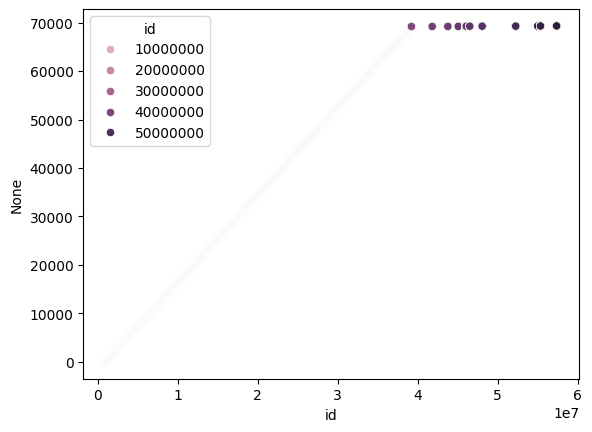

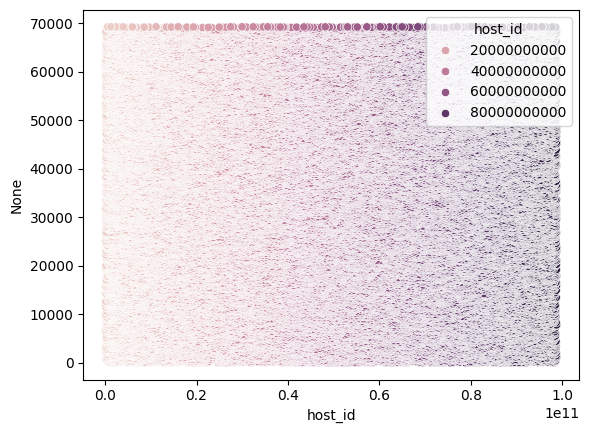

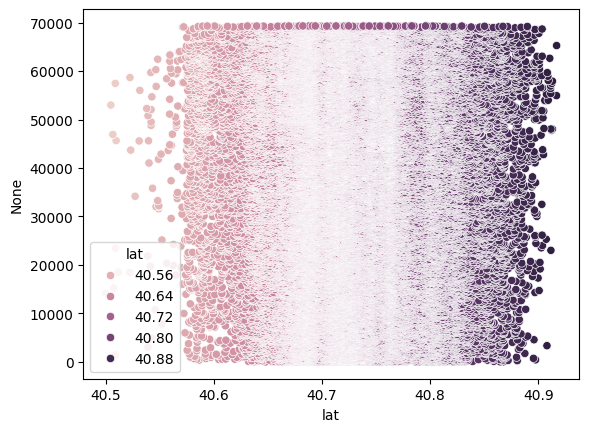

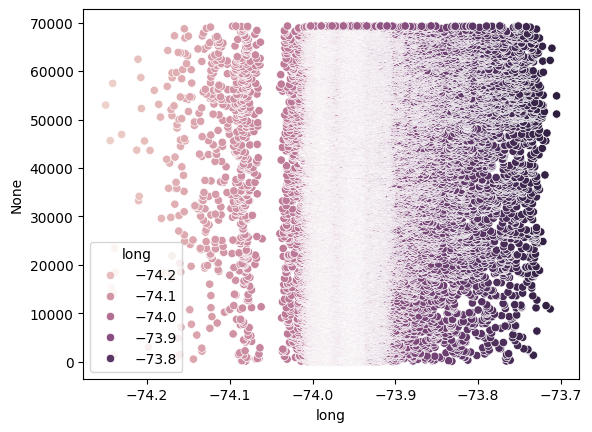

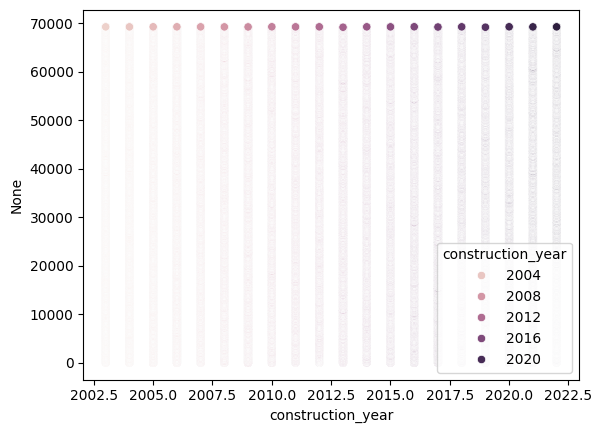

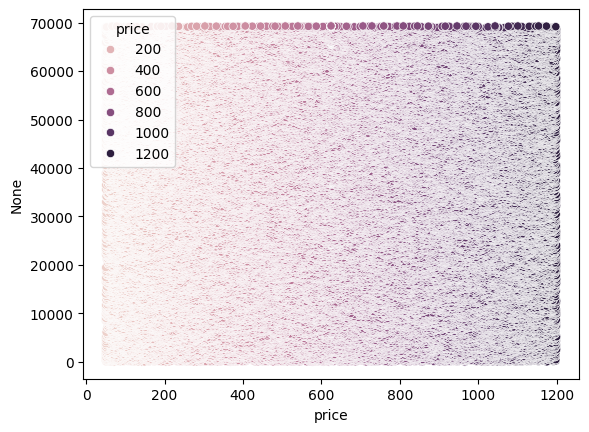

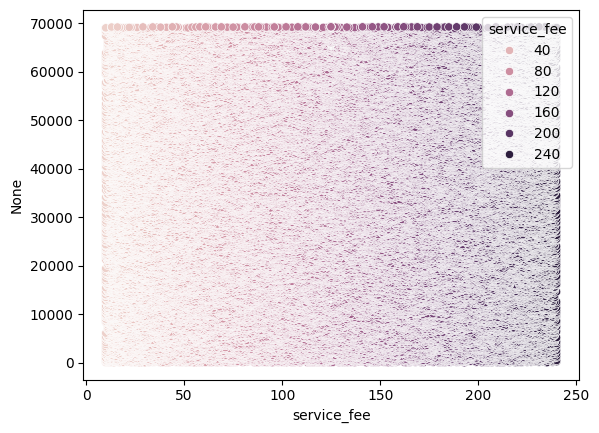

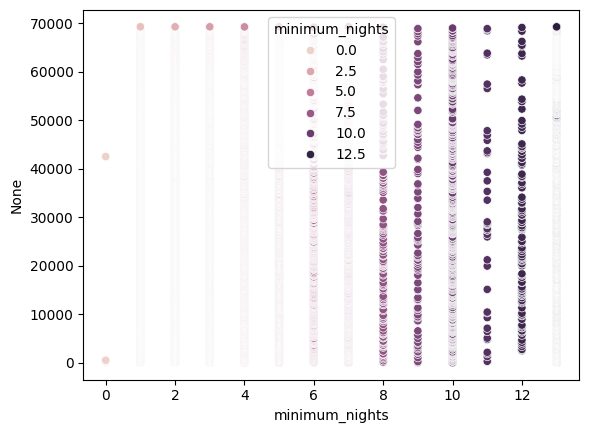

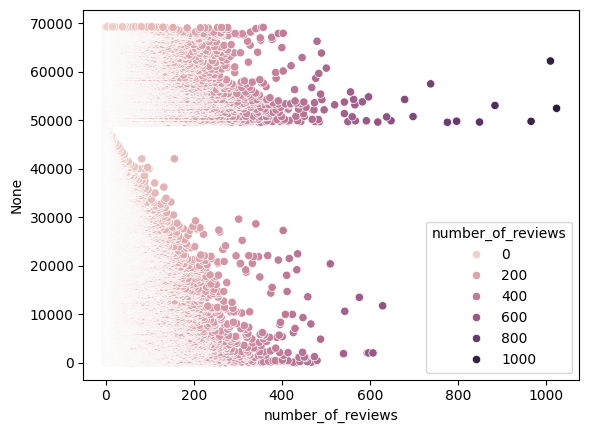

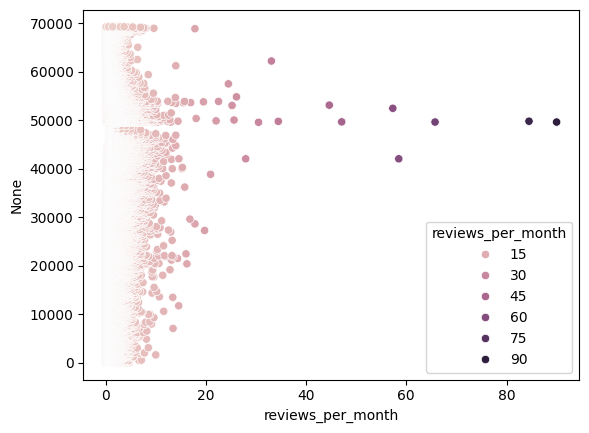

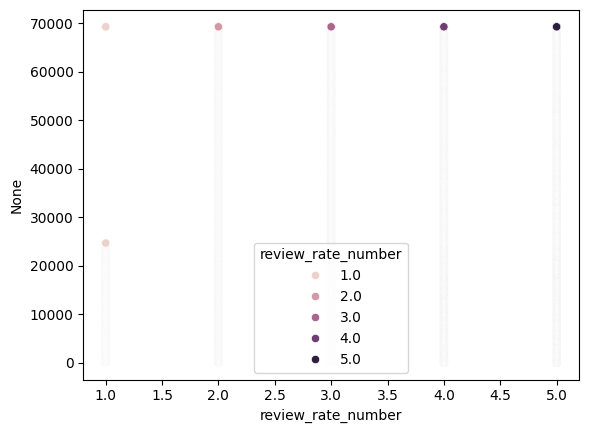

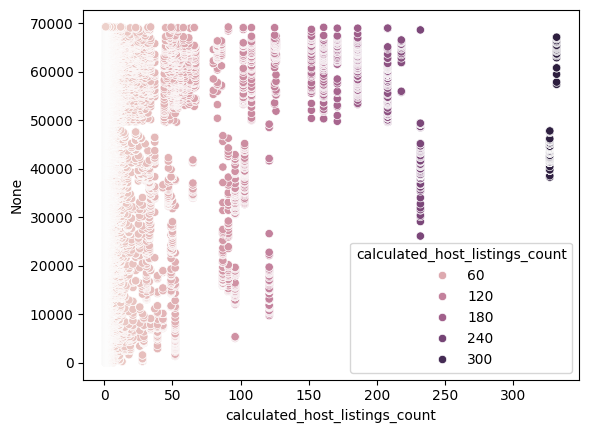

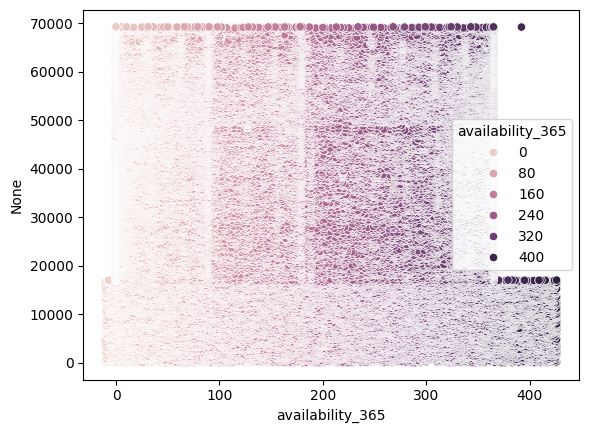

In [10]:
for col in df.columns :
    plt.figure()
    sns.scatterplot(data=df,x=df[col],y=df.index,hue=col)

C:\Users\BAPS\AppData\Local\Temp\ipykernel_12572\1423133827.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

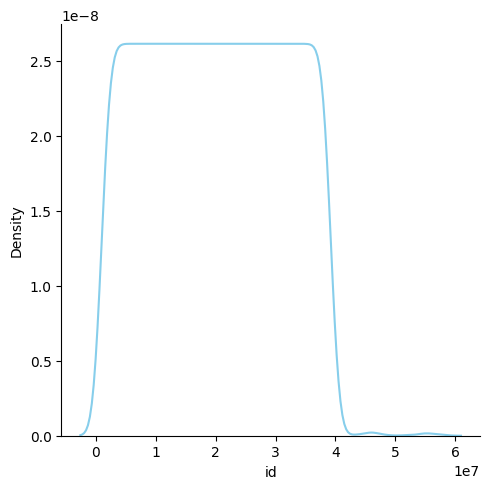

<Figure size 640x480 with 0 Axes>

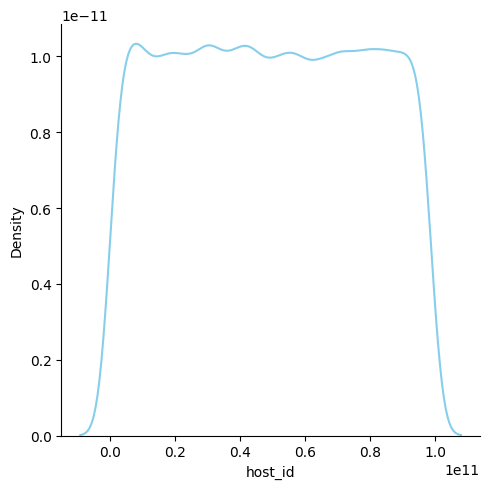

<Figure size 640x480 with 0 Axes>

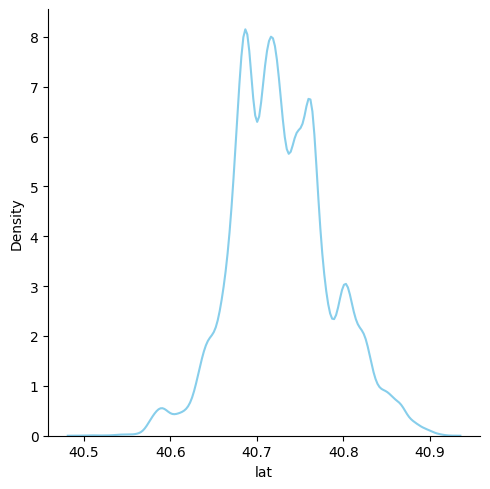

<Figure size 640x480 with 0 Axes>

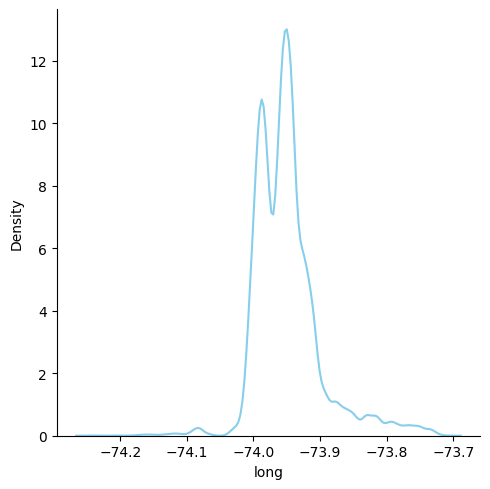

<Figure size 640x480 with 0 Axes>

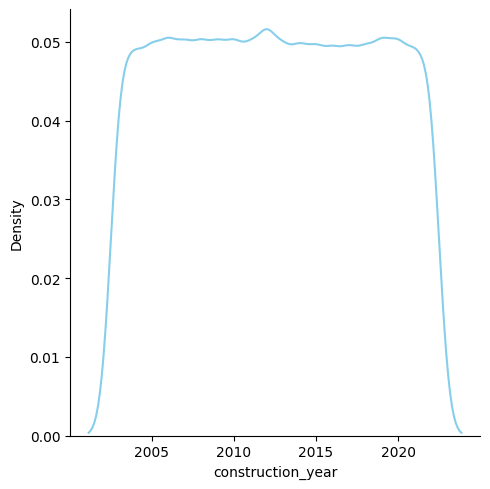

<Figure size 640x480 with 0 Axes>

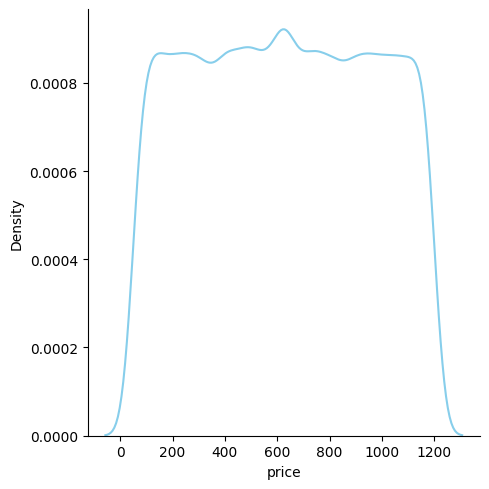

<Figure size 640x480 with 0 Axes>

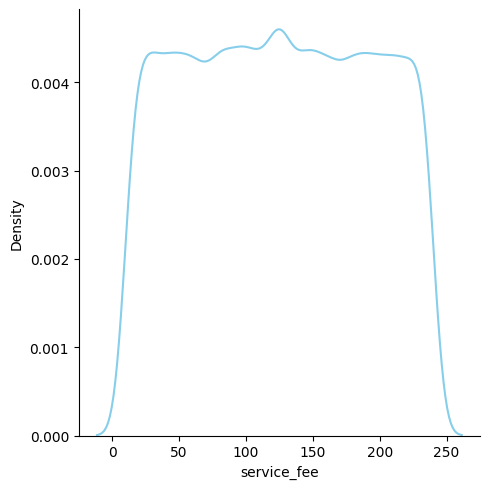

<Figure size 640x480 with 0 Axes>

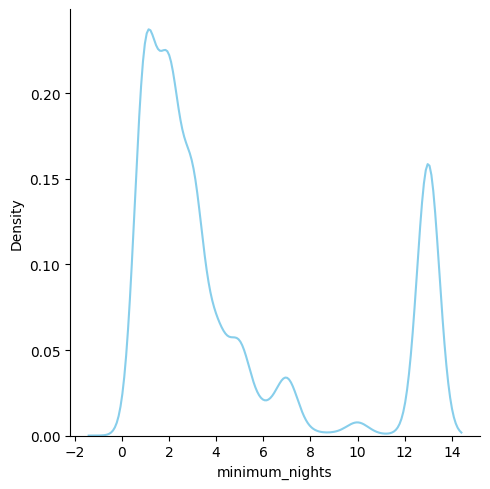

<Figure size 640x480 with 0 Axes>

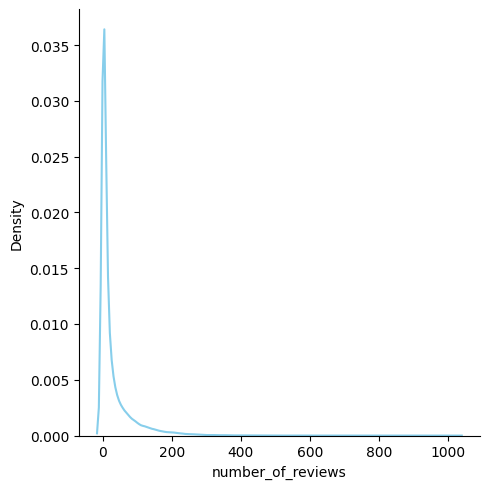

<Figure size 640x480 with 0 Axes>

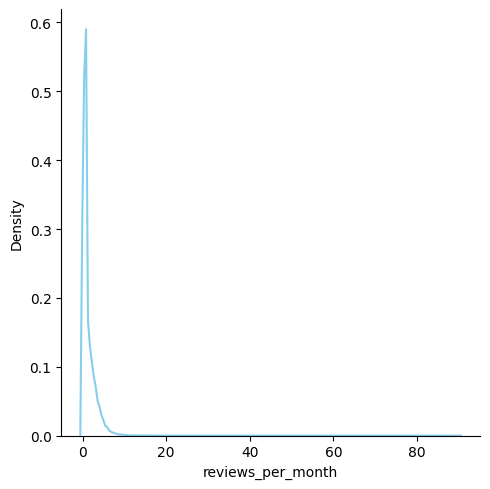

<Figure size 640x480 with 0 Axes>

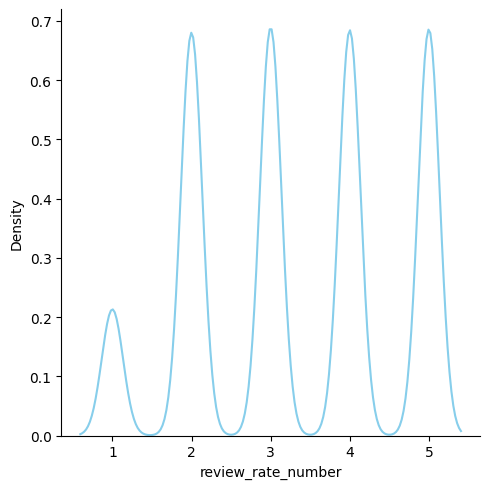

<Figure size 640x480 with 0 Axes>

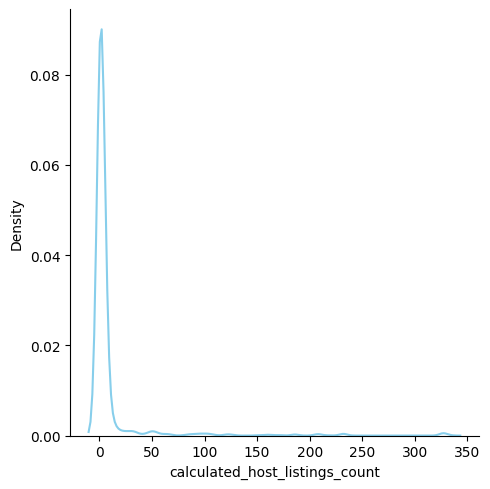

<Figure size 640x480 with 0 Axes>

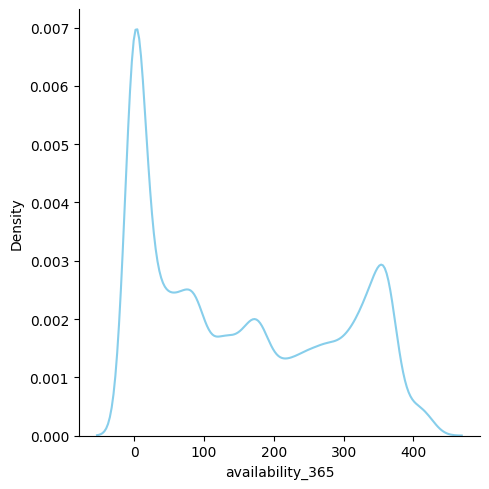

In [11]:
for col in df.columns:
    plt.figure()
    sns.displot(df[col],color='skyblue',kind='kde')

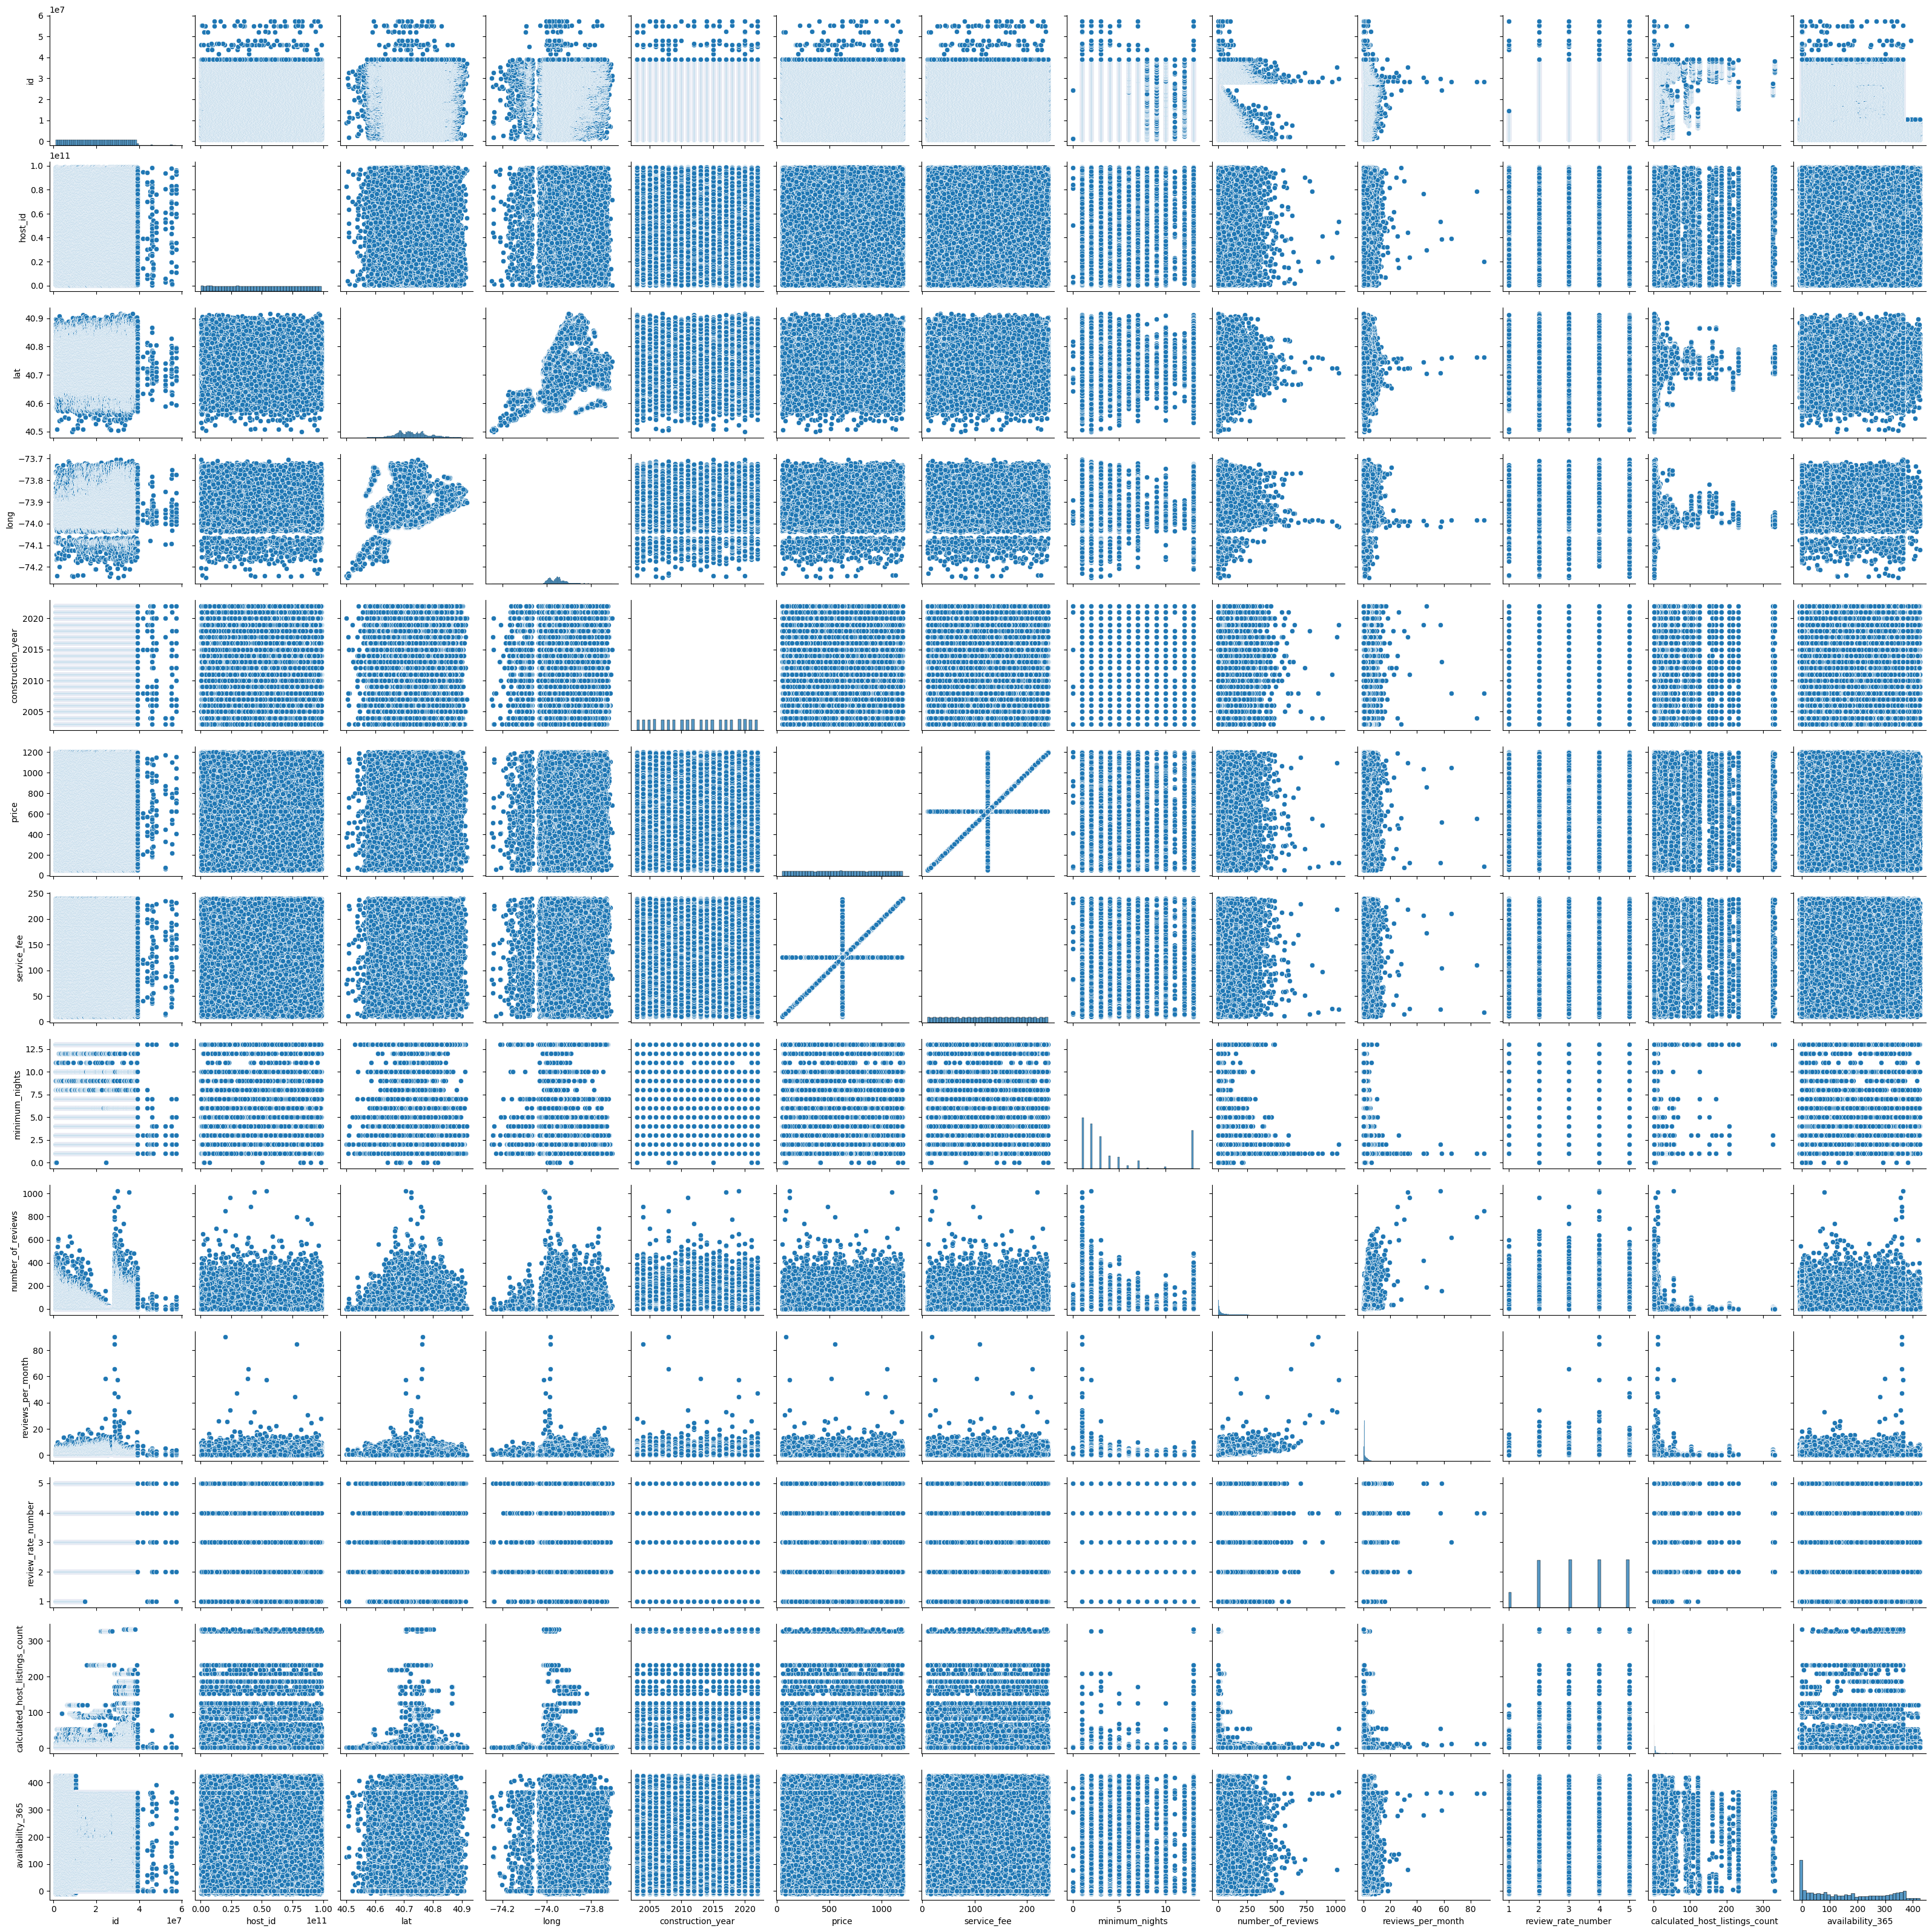

In [12]:
sns.pairplot(data=df)

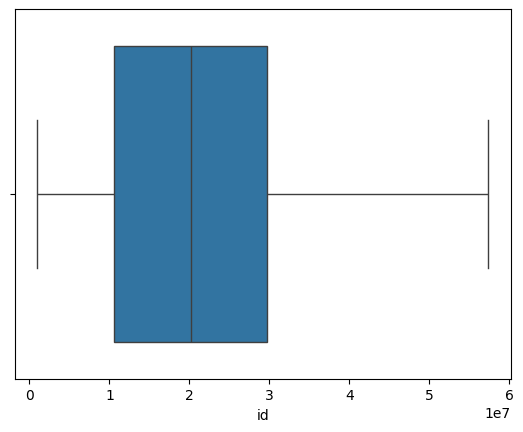

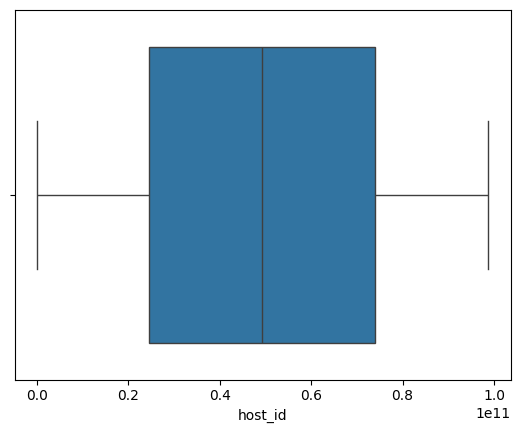

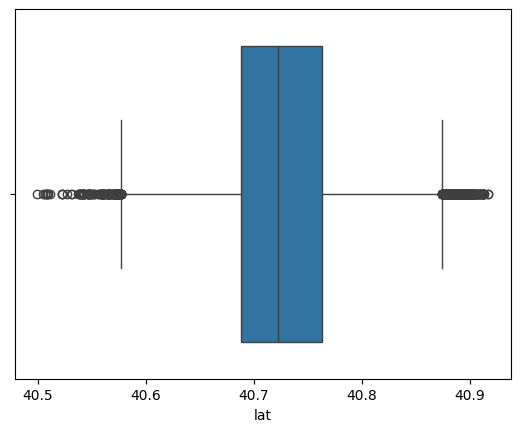

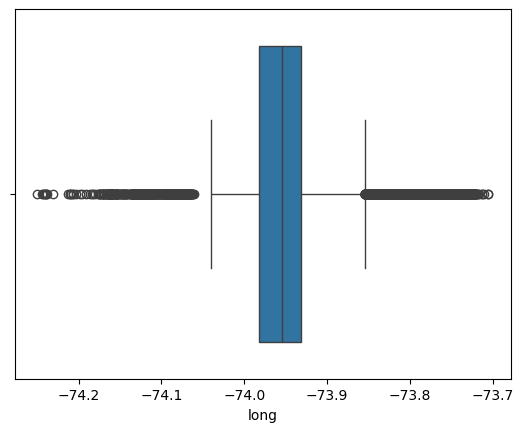

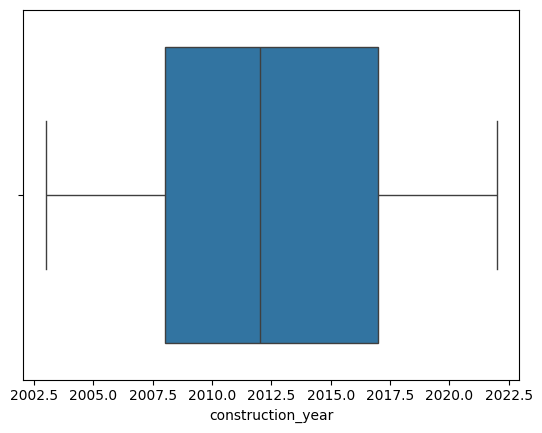

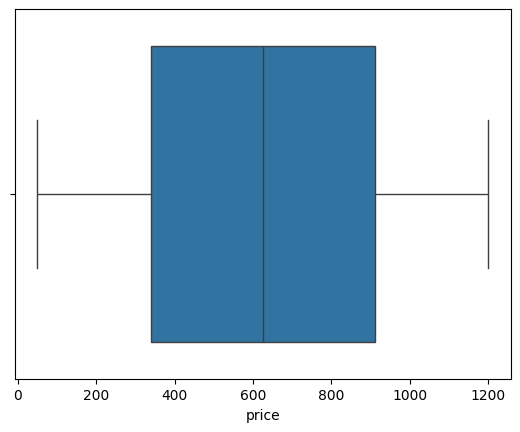

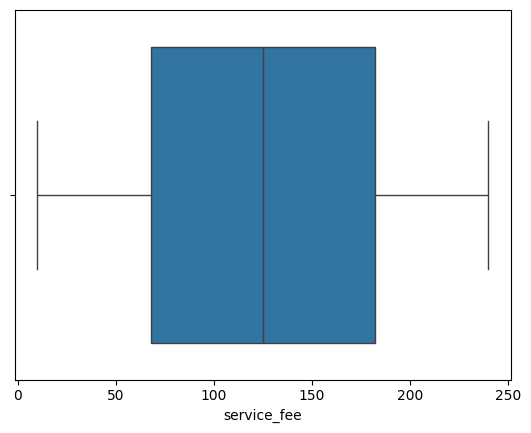

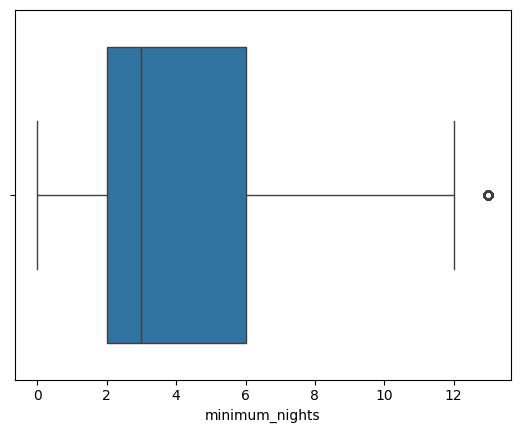

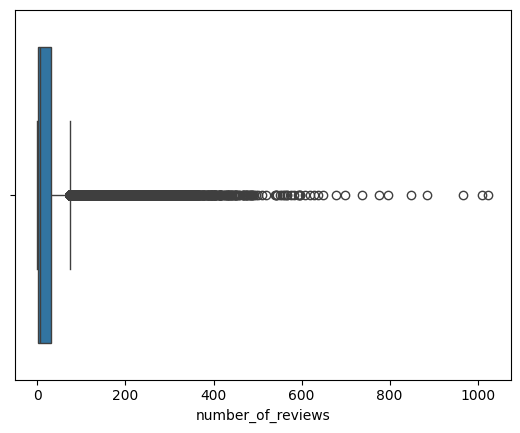

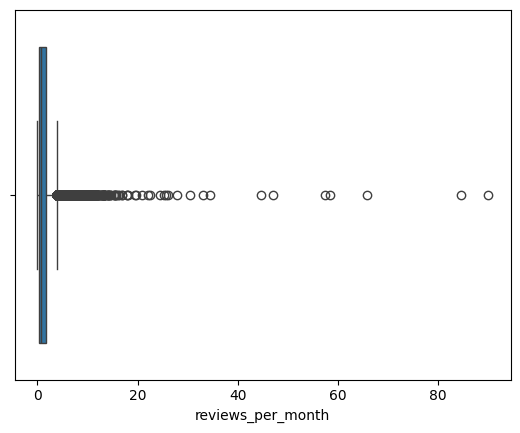

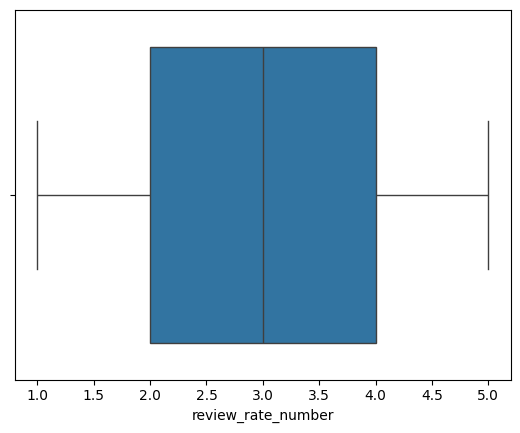

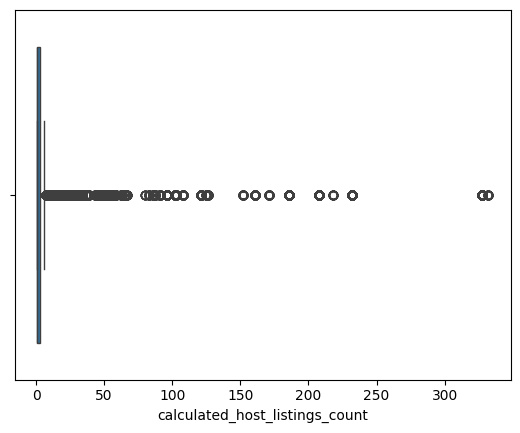

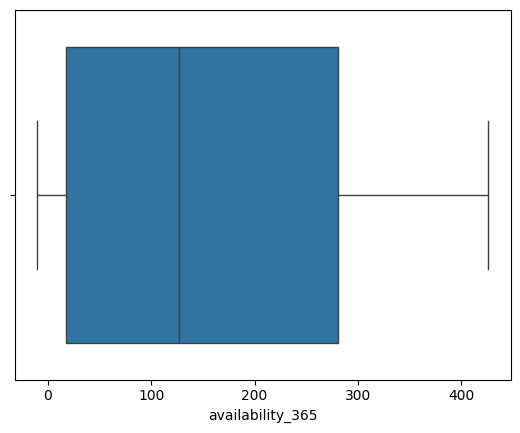

In [13]:
for column in df.columns :
    plt.figure()
    sns.boxplot(x = df[column], data = df)

In [14]:
corr=df.corr()
corr

,id,host_id,lat,long,construction_year,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
id,1.000000,-0.000977,-0.017637,0.111255,0.002726,0.008385,0.008339,0.175717,-0.041674,0.100222,0.156591,0.132629,-0.062533
host_id,-0.000977,1.000000,-0.000253,-0.003973,-0.000193,0.005970,0.005822,-0.000375,-0.003830,-0.001008,0.003791,0.004441,0.000496
lat,-0.017637,-0.000253,1.000000,0.064872,0.001712,-0.004253,-0.004194,0.039359,-0.026797,-0.023990,-0.003318,0.036674,-0.002391
long,0.111255,-0.003973,0.064872,1.000000,0.001094,0.005065,0.004780,-0.100202,0.058211,0.108019,0.017998,-0.105518,0.050854
construction_year,0.002726,-0.000193,0.001712,0.001094,1.000000,-0.001645,-0.001268,-0.004027,0.004357,0.005646,0.006313,-0.003831,-0.004002
price,0.008385,0.005970,-0.004253,0.005065,-0.001645,1.000000,0.997073,-0.001955,0.006575,0.005077,-0.001506,0.000595,-0.001785
service_fee,0.008339,0.005822,-0.004194,0.004780,-0.001268,0.997073,1.000000,-0.002067,0.006544,0.004995,-0.001289,0.000827,-0.002192
minimum_nights,0.175717,-0.000375,0.039359,-0.100202,-0.004027,-0.001955,-0.002067,1.000000,-0.127562,-0.272522,0.016415,0.228370,0.074307
number_of_reviews,-0.041674,-0.003830,-0.026797,0.058211,0.004357,0.006575,0.006544,-0.127562,1.000000,0.551162,-0.013252,-0.084275,0.074274
reviews_per_month,0.100222,-0.001008,-0.023990,0.108019,0.005646,0.005077,0.004995,-0.272522,0.551162,1.000000,0.034664,-0.035635,0.044403


In [15]:
df.shape

(69305, 13)

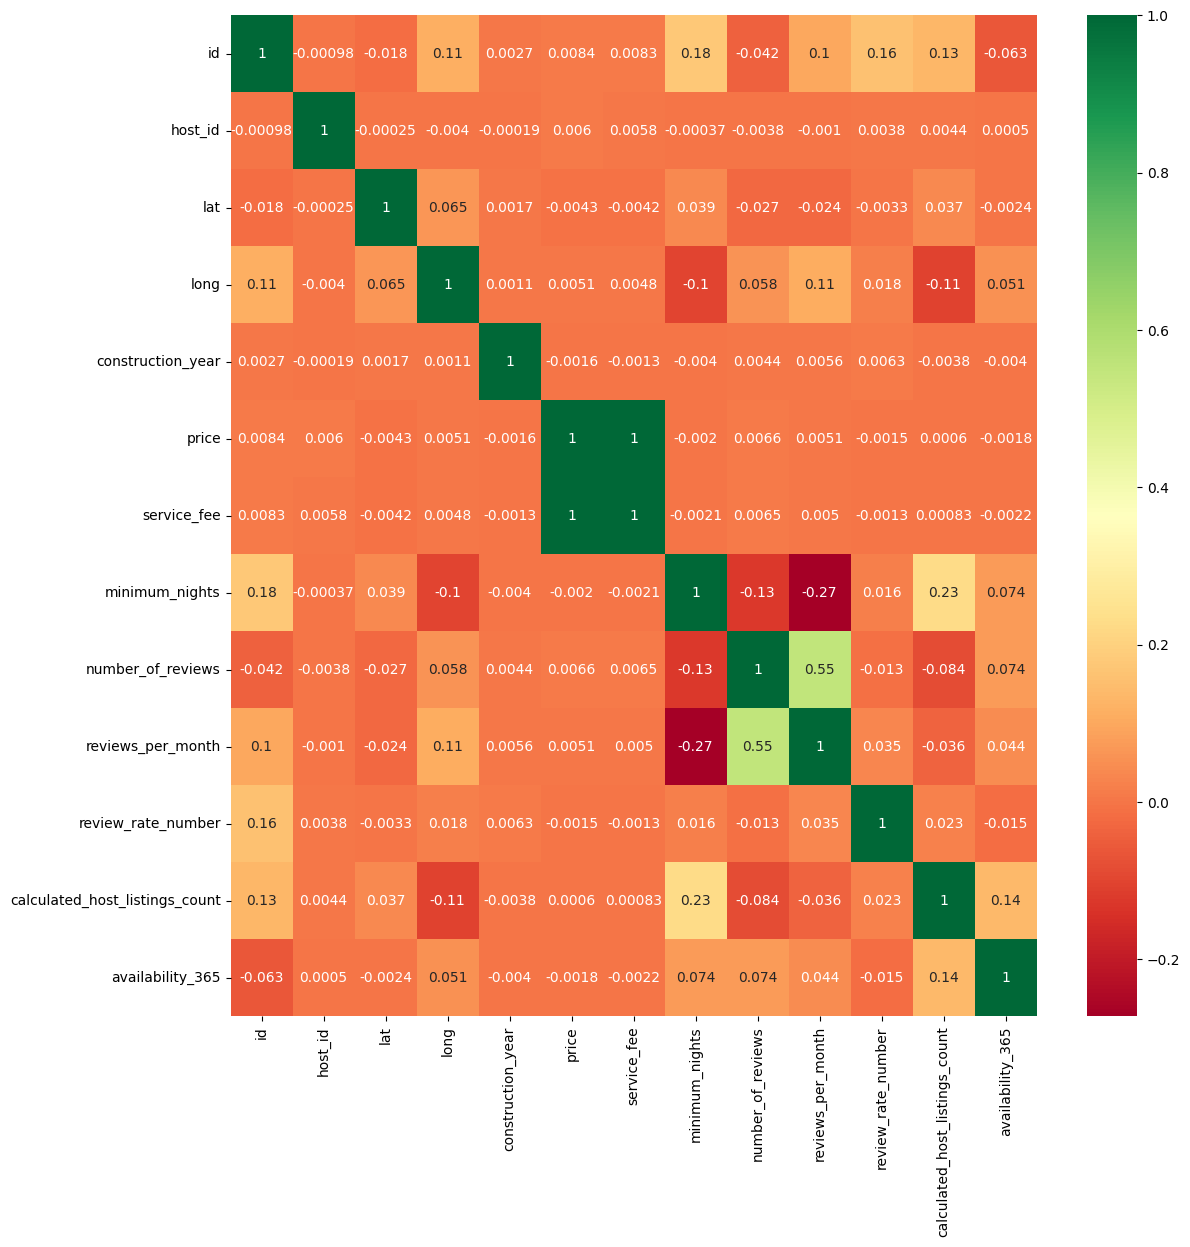

In [16]:
plt.subplots(figsize=(13,13))
sns.heatmap(corr,cmap='RdYlGn',annot=True)
plt.show()

In [17]:
skew = df.skew()
print("\nSkew\n")
print(skew)


Skew

id                                0.021827
host_id                           0.004266
lat                               0.214486
long                              1.246571
construction_year                 0.004561
price                             0.001848
service_fee                       0.002785
minimum_nights                    1.163166
number_of_reviews                 3.924162
reviews_per_month                 8.976864
review_rate_number               -0.137604
calculated_host_listings_count    6.538789
availability_365                  0.359776
dtype: float64


(<seaborn.axisgrid.FacetGrid at 0x2957e217a10>,
 np.float64(8.976863637767154),
 np.float64(90.0))

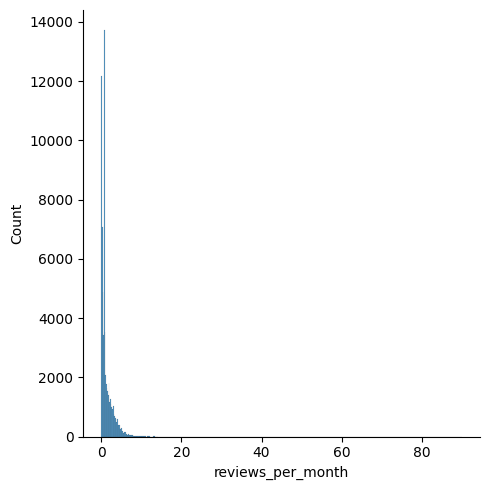

In [18]:
sns.displot(df['reviews_per_month']),df["reviews_per_month"].skew(),df['reviews_per_month'].max()

(<seaborn.axisgrid.FacetGrid at 0x2957e32e390>,
 np.float64(3.9241617468792733),
 np.float64(1024.0))

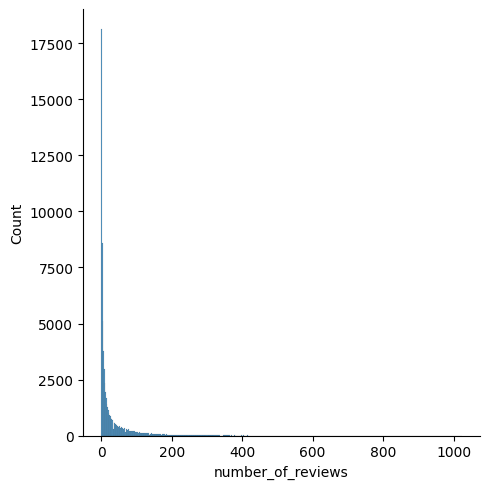

In [19]:
sns.displot(df['number_of_reviews']),df['number_of_reviews'].skew(),df["number_of_reviews"].max()

In [20]:
kurt = df.kurt()
print("\Kurt\n")
print(kurt)
## Observation : Skew and Kurt values are in range -3 to 3 then no need to have a transformation.

\Kurt

id                                 -1.139152
host_id                            -1.203777
lat                                 0.154057
long                                4.127319
construction_year                  -1.202227
price                              -1.188310
service_fee                        -1.187747
minimum_nights                     -0.254952
number_of_reviews                  25.873871
reviews_per_month                 311.589104
review_rate_number                 -1.111552
calculated_host_listings_count     47.551994
availability_365                   -1.328753
dtype: float64


<Figure size 1200x600 with 0 Axes>

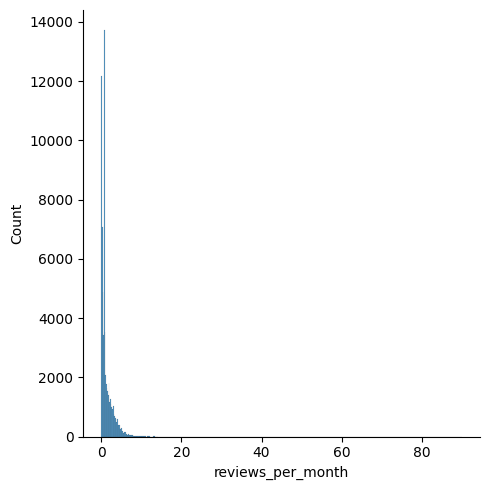

In [21]:
plt.figure(figsize=(12,6))
sns.displot(df['reviews_per_month'])
plt.show()

In [22]:
print('Before outlier removal : ',df.shape)
z = np.abs(zscore(df, axis = 1))
z1=(pd.DataFrame(z,columns=df.columns))
threshold = 3
dataset = df[(z < threshold).all(axis=1)]
print('After Z-Score approach : ',dataset.shape)

Before outlier removal :  (69305, 13)
After Z-Score approach :  (0, 13)


In [23]:
print('Before outlier removal : ',df.shape)
np.abs(zscore(df['host_id']))
threshold = 3.4641016
dataset = df['host_id'][(z < threshold).all(axis=1)]
print('After Z-Score approach : ',dataset.shape)

Before outlier removal :  (69305, 13)
After Z-Score approach :  (62640,)


In [24]:
dataset

10        1280143094
45        2107606817
51        1529890895
75        4726877402
80        6644226026
            ...     
69300    29964876857
69301    92852058426
69302    95572379802
69303    80154173698
69304    11145329848
Name: host_id, Length: 62640, dtype: int64

In [25]:
z_score=np.abs(df['host_id'])
threshold=3

In [26]:
dataset.info()

<class 'pandas.core.series.Series'>
Index: 62640 entries, 10 to 69304
Series name: host_id
Non-Null Count  Dtype
--------------  -----
62640 non-null  int64
dtypes: int64(1)
memory usage: 978.8 KB


In [27]:
for column in dataset.columns :
    plt.figure()
    sns.displot(dataset[column],color='darkorange',kind='kde')

AttributeError: 'Series' object has no attribute 'columns'

In [ ]:
for column in dataset.columns :
    plt.figure()
    sns.boxplot(x = dataset[column], data = dataset)

In [ ]:
skew1 = dataset.skew()
print("Skew1\t")
print(skew1)

print("\nSkew")
print(skew)
# print("\nKurt1\n")
# kurt1 = dataset.kurt()
# print(kurt1)

Skew1	
0.09575389296117945

Skew
id                                0.021827
host_id                           0.004266
lat                               0.214486
long                              1.246571
construction_year                 0.004561
price                             0.001848
service_fee                       0.002785
minimum_nights                    1.163166
number_of_reviews                 3.924162
reviews_per_month                 8.976864
review_rate_number               -0.137604
calculated_host_listings_count    6.538789
availability_365                  0.359776
dtype: float64


In [ ]:
df.shape

(69305, 13)

In [ ]:
# for i in df:
#     Q1 = np.percentile(df[i], 25, interpolation = 'midpoint') 
#     Q2 = np.percentile(df[i], 50, interpolation = 'midpoint') 
#     Q3 = np.percentile(df[i], 75, interpolation = 'midpoint') 

#     # Q1 = df.quantile(0.25)  # Q1
#     # Q3 = df.quantile(0.75)  # Q3
#     IQR = Q3-Q1
#     # dataset = df[~((df<(Q1-1.5*IQR)) | (df>(Q3+1.5*IQR)))]
#     # dataset = dataset[~((dataset<(Q1-1.5*IQR)) | (dataset>(Q3+1.5*IQR)))]
#     # print('After IQR approach : ',dataset.shape)
#     low_lim = Q1 - 1.5 * IQR
#     up_lim = Q3 + 1.5 * IQR
#     print('low_limit is', low_lim)
#     print('up_limit is', up_lim)
#     outlier =[]
#     for x in df[i]:
#         if ((x> up_lim) or (x<low_lim)):
#             outlier.append(x)
#     print(' outlier in the dataset is', outlier)
#     df[i] = df.drop(df[i]==outlier)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69305 entries, 0 to 69304
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              69305 non-null  int64  
 1   host_id                         69305 non-null  int64  
 2   lat                             69305 non-null  float64
 3   long                            69305 non-null  float64
 4   construction_year               69305 non-null  float64
 5   price                           69305 non-null  float64
 6   service_fee                     69305 non-null  float64
 7   minimum_nights                  69305 non-null  float64
 8   number_of_reviews               69305 non-null  float64
 9   reviews_per_month               69305 non-null  float64
 10  review_rate_number              69305 non-null  float64
 11  calculated_host_listings_count  69305 non-null  float64
 12  availability_365                

In [ ]:
# if ((df[x].mean()> up_lim) or (df[x].mean()<low_lim)):
# # outlier =[]
# # # for data in
# # for x in df:
# #     # print(x)
# #     if ((df[x].mean()> up_lim) or (df[x].mean()<low_lim)):
# #          outlier.append(x)
# # print(' outlier in the dataset is', outlier)